# EDIS 8100 · Week 11 · Co-Design Studio: Whose Dashboard Is This?

**Estimated time: about 25 minutes of code.** The rest of today is design dialogue, so this
notebook is deliberately light. Think of it as a sketchpad, not an analysis.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Represent stakeholders as data**: read a set of persona cards that carry goals, fears, and
   decision rights, and explain why decision rights change what a metric is allowed to mean.
2. **Sketch a view for one stakeholder**: choose a small set of metrics and render a quick plotly
   mock of what that person would see.
3. **Swap seats and critique**: examine the same sketch through a second persona's eyes, and use
   the data to check which of your metrics tell a systematically different story about which students.
4. **Audit your own semester**: decide, artifact by artifact from weeks 3 through 10, who should
   have had a voice in the design and did not.

## How this notebook works (read this if you are new to code)

- Run the cells **top to bottom**. Click a cell and press **Shift + Enter**.
- **Nothing here can break your computer.** Everything runs in a temporary cloud machine, and the
  data are invented. If you break something, you break a copy.
- If a cell errors, the usual fix is to **re-run from the top**: `Runtime > Restart and run all`.
- Cells marked **✏️ Your turn** already contain working values. The notebook runs end to end even if
  you change nothing, so you can read first and edit second.
- You never need to write code from scratch here. Every edit is changing a word inside quotes or
  a number in a list.

## ⚙️ Setup: run the next cell first

The next cell builds this week's three synthetic datasets and saves them into a `data/` folder
next to the notebook. It takes about a second.

The data are synthetic **on purpose**. We can rehearse the judgment calls of learning analytics
without anyone being surveilled to make our homework possible. The ask in return: treat these
rows as if they were real people.

In [1]:
# ⚙️ THIS CELL IS LONG ON PURPOSE. It is the seeded data generator, pasted in so the notebook
# works in Colab with zero downloads and zero setup. You do not need to read it.
# Collapse it (click the little arrow to the left) and move on.

"""EDIS 8100 data generation, the subset needed for week11.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GRADEBOOK = SEED + 2
SEED_MMLA = SEED + 5
SEED_STUDIO_CHAT = SEED + 20
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
def _studio_chat_counts(students: pd.DataFrame):
    """Messages and substantive idea units per student per studio session.

    Drawn once from a dedicated stream so that group_chat.csv and mmla_studio.csv
    tell the same story about who typed what. Multilingual students send at least
    as many messages and a higher share of substantive ones, which is half of P5.
    """
    rng = np.random.default_rng(SEED_STUDIO_CHAT)
    n = len(students)
    chat_prop = _z(students["chat_propensity"].to_numpy())
    multilingual = students["multilingual"].to_numpy()
    ability = students["ability"].to_numpy()

    lam = np.exp(1.72 + 0.38 * chat_prop + 0.19 * multilingual)
    p_sub = np.clip(0.34 + 0.055 * multilingual + 0.05 * ability, 0.10, 0.85)

    n_msgs = np.zeros((n, N_WEEKS), dtype=int)
    n_sub = np.zeros((n, N_WEEKS), dtype=int)
    for s in range(N_WEEKS):
        session_factor = float(rng.uniform(0.82, 1.22))
        msgs = rng.poisson(lam * session_factor)
        n_msgs[:, s] = msgs
        n_sub[:, s] = rng.binomial(msgs, p_sub)
    return n_msgs, n_sub
def make_mmla(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """One row per student per studio session, across five modalities.

    P5 lives here: multilingual students hold the floor less, and contribute at
    least as much through chat, idea units, and document edits. Anyone who reads
    only speaking_time_s will misdescribe them.

    P9 also starts here: groups differ in how evenly speaking time is spread, and
    studio_artifacts.csv scores the products those groups made.
    """
    rng = np.random.default_rng(SEED_MMLA)
    students = make_students(write=False)
    n_msgs, n_sub = _studio_chat_counts(students)

    sid = students["student_id"].to_numpy()
    gid = students["group_id"].to_numpy()
    talk = students["talkativeness"].to_numpy()
    multilingual = students["multilingual"].to_numpy()
    doc_prop = _z(students["doc_propensity"].to_numpy())

    group_names = [f"G{g + 1:02d}" for g in range(N_GROUPS)]
    members = {g: np.where(gid == g)[0] for g in group_names}

    # How evenly the floor is shared in each group. Low alpha means one or two
    # people dominate every session.
    group_alpha = np.exp(rng.normal(1.30, 0.62, N_GROUPS))
    group_alpha = np.clip(group_alpha, 0.8, 14.0)

    rows = []
    for s in range(N_WEEKS):
        session_id = f"studio_{s + 1}"
        for g_i, g in enumerate(group_names):
            idx = members[g]
            w = np.exp(0.55 * talk[idx] - 0.26 * multilingual[idx])
            alpha = group_alpha[g_i] * w / w.mean()
            shares = rng.dirichlet(np.clip(alpha, 0.15, None))

            total_speech = float(rng.normal(3050, 260))
            total_turns = int(rng.integers(150, 260))

            # Even a student who barely speaks says something, so nobody is a flat zero.
            speaking = np.round(np.maximum(shares * total_speech, rng.uniform(3, 22, len(idx))), 1)
            turns = np.maximum(1, rng.poisson(np.clip(shares * total_turns, 0.7, None)))
            avg_turn = np.round(speaking / turns, 1)
            interruptions = rng.poisson(np.clip(0.6 + 9.0 * shares, 0.05, None))
            gaze_peer = np.clip(
                rng.normal(38 + 26 * (shares - 0.2) + 3.0 * multilingual[idx], 6.0), 8, 72
            )
            gaze_material = np.clip(rng.normal(74 - gaze_peer * 0.55, 7.0), 10, 70)
            over = np.maximum(0.0, gaze_peer + gaze_material - 94.0)
            gaze_material = gaze_material - over
            gestures = rng.poisson(np.clip(5 + 42 * shares, 0.5, None))
            doc_edits = rng.poisson(
                np.clip(3.4 + 2.4 * doc_prop[idx] + 1.2 * multilingual[idx], 0.4, None)
            )

            for j, i in enumerate(idx):
                rows.append(
                    {
                        "session_id": session_id,
                        "group_id": g,
                        "student_id": sid[i],
                        "speaking_time_s": float(speaking[j]),
                        "num_turns": int(turns[j]),
                        "interruptions": int(interruptions[j]),
                        "avg_turn_length_s": float(avg_turn[j]),
                        "gaze_peer_pct": round(float(gaze_peer[j]), 1),
                        "gaze_material_pct": round(float(gaze_material[j]), 1),
                        "gesture_count": int(gestures[j]),
                        "chat_messages": int(n_msgs[i, s]),
                        "doc_edits": int(doc_edits[j]),
                        "idea_units_chat": int(n_sub[i, s]),
                    }
                )

    df = pd.DataFrame(rows)
    df = df.sort_values(["session_id", "group_id", "student_id"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "mmla_studio.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_gradebook(outdir=outdir)
    make_mmla(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   gradebook.csv
   mmla_studio.csv
   students.csv


### ⚙️ Load the tools and the data

Three files, three grains:

| File | One row is | Why we need it today |
|---|---|---|
| `students.csv` | one student | who is in the room, and which students a metric might misread |
| `gradebook.csv` | one student on one assessment | the outcome numbers stakeholders argue about |
| `mmla_studio.csv` | one student in one studio session | how participation looked across several channels at once |

We are not doing statistics today. We are deciding **what deserves to be on a screen**, and we
want real numbers under the sketch so the design argument has something to push against.

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Colab knows how to draw plotly figures on its own. Anywhere else we ask for the
# lightweight renderer, which keeps the saved notebook small. Nothing to edit here.
try:
    import google.colab  # noqa: F401
except ImportError:
    pio.renderers.default = 'plotly_mimetype'

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

students = pd.read_csv('data/students.csv')
gradebook = pd.read_csv('data/gradebook.csv', parse_dates=['submitted_at', 'deadline'])
mmla = pd.read_csv('data/mmla_studio.csv')

print('students  :', students.shape[0], 'rows')
print('gradebook :', gradebook.shape[0], 'rows')
print('mmla      :', mmla.shape[0], 'rows')
students.head(3)

students  : 120 rows
gradebook : 1080 rows
mmla      : 960 rows


,student_id,first_name,last_name,gender,first_gen,multilingual,work_hours_per_week,prior_gpa,major_area
0,S001,Avery,Kim,nonbinary,1,0,23,3.38,nursing
1,S002,Hana,Mbeki,woman,1,0,16,3.38,data science
2,S003,Tanvi,Nakamura,woman,1,0,29,3.03,engineering


## 1. 🧑‍🤝‍🧑 Four people, written down as data

A persona is not a demographic sketch. For design purposes the useful parts of a person are:

- **Goals**: what they are actually trying to accomplish this week.
- **Fears**: what a bad version of this tool would do to them.
- **Decision rights**: what they are allowed to change once they see the number. This is the part
  most dashboards skip, and it is the part Bang and Vossoughi (2016) would say carries the power
  relations. A metric handed to someone with no authority to act on it is not information, it is pressure.
- **Grain**: whether they need the whole class at once, or one person over time.
- **Access reality**: what the institution would actually let them see. Sometimes the honest answer
  is "nothing", and that is a design finding rather than an obstacle.

Below, the four personas live in a plain Python dictionary. They are data, so we can compute with
them later: cross them against metrics, sort them, put them on an axis.

In [3]:
PERSONAS = {
    'teacher': dict(
        emoji='🧑‍🏫',
        name='Dana Okonkwo',
        role='Instructor of record, EDUC 1010 (120 students, 24 studio groups)',
        goals=[
            'Notice by Thursday who needs a conversation, while there is still course left',
            'Find out whether the studio redesign is working, or only working for the loud groups',
        ],
        fears=[
            'Acting on a number that is simply wrong about a student',
            'Being handed a list of 30 names and 3 hours to act on it',
            'The tool being used on her by an administrator instead of by her on the course',
        ],
        decision_rights=[
            'What happens in class next Thursday',
            'Who gets an email, and how it is worded',
            'How studio groups are composed and how the rubric is written',
        ],
        cannot_change=['The roster', 'Institutional policy', 'What the LMS logs'],
        grain='class',
        access_reality='Full gradebook and LMS access for her own section.',
        question='Who is about to fall out of reach, and what would I actually do about it?',
    ),
    'student': dict(
        emoji='🎓',
        name='Malik Ferrer',
        role='Second-year undergraduate in EDUC 1010, works 20 hours a week off campus',
        goals=[
            'Know what to do next, not only where he ranks',
            'Get credit for the ways he actually contributes to his studio group',
        ],
        fears=[
            'A metric that reads his quiet studio sessions as not caring',
            'A number that follows him into next semester with no context attached',
            'Being compared to classmates in public',
        ],
        decision_rights=[
            'How he spends his study hours this week',
            'Whether to go to office hours or to the writing center',
            'Whether to consent to his data being shown to anyone else',
        ],
        cannot_change=['What the LMS collects', 'How the rubric weights participation'],
        grain='self',
        access_reality='Sees his own grades. Usually sees none of the process data about himself.',
        question='What does this say I should do differently, and is it even about me?',
    ),
    'advisor': dict(
        emoji='🗂️',
        name='Ana Whitfield',
        role='Academic advisor, about 300 first- and second-year advisees',
        goals=[
            'Spot advisees whose trajectory is bending down across courses, not just in one',
            'Spend her 20 advising hours a week where they will change an outcome',
        ],
        fears=[
            'False alarms that burn her credibility with students and with faculty',
            'A single-course signal being read as a whole-person signal',
            'Deficit language landing in an advising note that follows a student for years',
        ],
        decision_rights=[
            'Who she reaches out to this month',
            'Referrals to tutoring, financial aid, disability services',
            'Registration advice and course load recommendations',
        ],
        cannot_change=['Grades', 'Course design', 'A student work schedule'],
        grain='individual-over-time',
        access_reality='Sees grades across courses, rarely sees anything from inside a course.',
        question='Is this one bad week, or a pattern I should call about?',
    ),
    'parent': dict(
        emoji='👪',
        name='Bea Njoroge',
        role='Parent of a first-year student, paying part of tuition',
        goals=[
            'Know whether to worry',
            'Know how to help without hovering',
        ],
        fears=[
            'Seeing a number with no context and reacting badly at Sunday dinner',
            'Her student losing autonomy the moment she can see the data',
            'Dashboards replacing the conversation she would otherwise have',
        ],
        decision_rights=[
            'Family conversations',
            'Financial and logistical support',
            'Encouragement, and when to back off',
        ],
        cannot_change=['Anything inside the course or the system'],
        grain='self-of-another',
        access_reality=('In US higher education, FERPA generally gives her no access without her '
                        'student consenting. Designing for her means designing the consent, not the panel.'),
        question='Is my kid okay, and is it my business?',
    ),
}

def show_persona(key):
    p = PERSONAS[key]
    line = '=' * 78
    print(line)
    print(f"{p['emoji']}  {p['name']}  ({key})")
    print(f"   {p['role']}")
    print(f"   Their question: \"{p['question']}\"")
    print(f"   Grain they think in: {p['grain']}   |   Access reality: {p['access_reality']}")
    for label, items in [('GOALS', p['goals']), ('FEARS', p['fears']),
                         ('DECISION RIGHTS', p['decision_rights']), ('CANNOT CHANGE', p['cannot_change'])]:
        print(f"   {label}:")
        for it in items:
            print(f"      - {it}")

for k in PERSONAS:
    show_persona(k)
print('=' * 78)

🧑‍🏫  Dana Okonkwo  (teacher)
   Instructor of record, EDUC 1010 (120 students, 24 studio groups)
   Their question: "Who is about to fall out of reach, and what would I actually do about it?"
   Grain they think in: class   |   Access reality: Full gradebook and LMS access for her own section.
   GOALS:
      - Notice by Thursday who needs a conversation, while there is still course left
      - Find out whether the studio redesign is working, or only working for the loud groups
   FEARS:
      - Acting on a number that is simply wrong about a student
      - Being handed a list of 30 names and 3 hours to act on it
      - The tool being used on her by an administrator instead of by her on the course
   DECISION RIGHTS:
      - What happens in class next Thursday
      - Who gets an email, and how it is worded
      - How studio groups are composed and how the rubric is written
   CANNOT CHANGE:
      - The roster
      - Institutional policy
      - What the LMS logs
🎓  Malik Ferrer  

**Read before you scroll past.** Two of these people can change something about the course itself.
Two of them can only change how they talk to a person. Which two are which, and what does that
imply about the *tone* a view should take for each?

Notice also that no persona is a data type. "Parent" is not a row in a table anywhere in this
course's data universe. Prieto-Alvarez, Martinez-Maldonado, and Anderson (2018) would point out
that the people most affected by a learning analytics tool are frequently the people with no
representation in the schema at all.

## 2. 📊 The metric menu

You cannot co-design in the abstract, so here is a real menu. Each metric below is computed from
the actual data, one number per student, so when you put one on a screen you are putting a real
distribution on a screen.

Every metric carries three annotations that matter more than its formula:

- **direction**: is more of this better? For several of these the honest answer is *contested*, and
  the contest is the design conversation.
- **what it is often mistaken for**: the leap a tired reader will make at 4:45 on a Thursday.
- **who can act on it**: scored per persona, `0` cannot act, `1` can act only after a conversation,
  `2` can act directly this week.

The `fears` column flags which persona's stated fear this metric pokes.

In [4]:
# ---- per-student metrics from the gradebook -------------------------------
quizzes = gradebook[gradebook['assessment'].str.startswith('quiz')].copy()
quizzes['quiz_number'] = quizzes['assessment'].str.split('_').str[1].astype(int)
quizzes['hours_before_deadline'] = (
    (quizzes['deadline'] - quizzes['submitted_at']).dt.total_seconds() / 3600.0
)

# quiz_trend is the least-squares slope of score against quiz number, computed for all
# 120 students at once. Everyone has all eight quizzes, so the x values are the same for all.
quiz_matrix = quizzes.pivot(index='student_id', columns='quiz_number', values='score')
x_centered = quiz_matrix.columns.values.astype(float)
x_centered = x_centered - x_centered.mean()
y_centered = quiz_matrix.values - quiz_matrix.values.mean(axis=1, keepdims=True)
trend = pd.Series(y_centered @ x_centered / (x_centered ** 2).sum(), index=quiz_matrix.index)

grades = pd.DataFrame({
    'avg_quiz': quizzes.groupby('student_id')['score'].mean(),
    'quiz_trend': trend,
    'low_quiz_count': quizzes.assign(low=quizzes['score'] < 70).groupby('student_id')['low'].sum(),
    'last_minute_rate': (quizzes.assign(lm=quizzes['hours_before_deadline'] < 6)
                                 .groupby('student_id')['lm'].mean() * 100),
})

# ---- per-student metrics from the studio sessions -------------------------
group_total = mmla.groupby(['session_id', 'group_id'])['speaking_time_s'].transform('sum')
mmla_share = mmla.assign(talk_share=mmla['speaking_time_s'] / group_total * 100)

studio = pd.DataFrame({
    'talk_minutes': mmla.groupby('student_id')['speaking_time_s'].mean() / 60.0,
    'talk_share': mmla_share.groupby('student_id')['talk_share'].mean(),
    'speaking_turns': mmla.groupby('student_id')['num_turns'].mean(),
    'ideas_in_chat': mmla.groupby('student_id')['idea_units_chat'].mean(),
    'doc_edits': mmla.groupby('student_id')['doc_edits'].mean(),
    'interruptions': mmla.groupby('student_id')['interruptions'].mean(),
    'gaze_at_peers': mmla.groupby('student_id')['gaze_peer_pct'].mean(),
})

M = (students.set_index('student_id')
     .join(grades).join(studio)
     .assign(full_name=lambda d: d['first_name'] + ' ' + d['last_name']))

METRIC_KEYS = ['avg_quiz', 'quiz_trend', 'low_quiz_count', 'last_minute_rate',
               'talk_minutes', 'talk_share', 'speaking_turns',
               'ideas_in_chat', 'doc_edits', 'interruptions', 'gaze_at_peers']

print('Metric table built:', M.shape[0], 'students x', len(METRIC_KEYS), 'metrics')
M[METRIC_KEYS].describe().round(2)

Metric table built: 120 students x 11 metrics


,avg_quiz,quiz_trend,low_quiz_count,last_minute_rate,talk_minutes,talk_share,speaking_turns,ideas_in_chat,doc_edits,interruptions,gaze_at_peers
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,75.73,0.03,2.58,21.67,10.24,20.00,40.63,2.39,3.86,2.36,38.57
std,11.59,1.27,2.83,29.78,5.75,11.28,22.80,1.16,2.32,1.15,3.75
min,43.85,-3.38,0.00,0.00,0.37,0.72,2.88,0.12,0.12,0.38,28.11
25%,68.75,-1.03,0.00,0.00,5.73,11.43,23.91,1.59,1.88,1.50,36.18
50%,76.09,0.09,1.00,12.50,9.43,18.02,38.62,2.25,3.81,2.12,38.42
75%,82.16,0.85,5.00,25.00,13.79,27.31,54.59,2.88,5.28,3.12,40.93
max,99.51,3.08,8.00,100.00,33.44,67.15,139.25,6.62,9.75,7.25,52.70


In [5]:
# The catalog: what each metric is, and what it does to each persona.
# act scores: 0 = cannot act on it, 1 = can act after a conversation, 2 = can act directly this week.
CATALOG = pd.DataFrame([
    dict(metric='avg_quiz', label='Average quiz score', unit='points',
         direction='higher is better', mistaken_for='how much this student has learned',
         act_teacher=2, act_student=1, act_advisor=2, act_parent=1, fears='student,parent'),
    dict(metric='quiz_trend', label='Quiz trajectory (points per week)', unit='points/week',
         direction='higher is better', mistaken_for='effort, or momentum',
         act_teacher=2, act_student=2, act_advisor=2, act_parent=1, fears='student'),
    dict(metric='low_quiz_count', label='Quizzes scored below 70', unit='count of 8',
         direction='lower is better', mistaken_for='a student in trouble',
         act_teacher=2, act_student=1, act_advisor=2, act_parent=0, fears='student,advisor,parent'),
    dict(metric='last_minute_rate', label='Quizzes submitted in the final 6 hours', unit='percent',
         direction='contested', mistaken_for='procrastination, and then a character flaw',
         act_teacher=1, act_student=2, act_advisor=1, act_parent=0, fears='student,parent'),
    dict(metric='talk_minutes', label='Studio speaking time', unit='minutes/session',
         direction='contested', mistaken_for='engagement, or confidence',
         act_teacher=2, act_student=1, act_advisor=0, act_parent=0, fears='student'),
    dict(metric='talk_share', label='Share of the group speaking time', unit='percent',
         direction='contested', mistaken_for='dominance, or its opposite',
         act_teacher=2, act_student=1, act_advisor=0, act_parent=0, fears='student'),
    dict(metric='speaking_turns', label='Speaking turns per session', unit='turns',
         direction='contested', mistaken_for='participation',
         act_teacher=2, act_student=1, act_advisor=0, act_parent=0, fears='student'),
    dict(metric='ideas_in_chat', label='Substantive ideas contributed in chat', unit='ideas/session',
         direction='higher is better', mistaken_for='chattiness',
         act_teacher=2, act_student=1, act_advisor=0, act_parent=0, fears=''),
    dict(metric='doc_edits', label='Edits to the shared document', unit='edits/session',
         direction='contested', mistaken_for='doing the work, or doing all the work',
         act_teacher=1, act_student=1, act_advisor=0, act_parent=0, fears=''),
    dict(metric='interruptions', label='Starting while someone else is speaking', unit='per session',
         direction='contested', mistaken_for='rudeness, or eagerness',
         act_teacher=1, act_student=2, act_advisor=0, act_parent=0, fears='student'),
    dict(metric='gaze_at_peers', label='Gaze directed at group members', unit='percent of session',
         direction='contested', mistaken_for='attention',
         act_teacher=0, act_student=0, act_advisor=0, act_parent=0, fears='student,teacher'),
]).set_index('metric').loc[METRIC_KEYS]

CATALOG[['label', 'unit', 'direction', 'mistaken_for']]

,label,unit,direction,mistaken_for
metric,,,,
avg_quiz,Average quiz score,points,higher is better,how much this student has learned
quiz_trend,Quiz trajectory (points per week),points/week,higher is better,"effort, or momentum"
low_quiz_count,Quizzes scored below 70,count of 8,lower is better,a student in trouble
last_minute_rate,Quizzes submitted in the final 6 hours,percent,contested,"procrastination, and then a character flaw"
talk_minutes,Studio speaking time,minutes/session,contested,"engagement, or confidence"
talk_share,Share of the group speaking time,percent,contested,"dominance, or its opposite"
speaking_turns,Speaking turns per session,turns,contested,participation
ideas_in_chat,Substantive ideas contributed in chat,ideas/session,higher is better,chattiness
doc_edits,Edits to the shared document,edits/session,contested,"doing the work, or doing all the work"


**Interpretation prompt.** Seven of the eleven metrics are marked *contested*, and one of them
(`gaze_at_peers`) nobody can act on at all. Carvalho and colleagues (2022) argue that design for
learning in an AI world has to start from the activity and its purposes rather than from what the
sensors happen to emit. `gaze_at_peers` exists in this dataset because a camera could produce it.
Say out loud what would have to be true for it to earn a place on a screen.

## 3. ✏️ Your turn: pick a persona and pick your metrics

Change the three values in the next cell. **Working defaults are already filled in**, so if you run
it untouched everything downstream still works.

- `MY_PERSONA`: one of `'teacher'`, `'student'`, `'advisor'`, `'parent'`.
- `MY_METRICS`: two to four keys from `METRIC_KEYS` (printed above). Fewer is braver.
- `FOCUS_STUDENT`: a `student_id` between `S001` and `S120` for the individual panel.

Constraint that makes this a design exercise rather than a shopping trip: **four metrics maximum.**
Every metric you add costs the reader attention, and attention is the scarce resource in the room
where the dashboard gets used.

In [6]:
# ✏️ EDIT THESE THREE LINES (or run as-is)
MY_PERSONA = 'teacher'
MY_METRICS = ['avg_quiz', 'quiz_trend', 'talk_share', 'ideas_in_chat']
FOCUS_STUDENT = 'S022'

# --- validation, so a typo tells you instead of failing weirdly later ---
assert MY_PERSONA in PERSONAS, f"MY_PERSONA must be one of {list(PERSONAS)}"
assert 1 <= len(MY_METRICS) <= 4, 'Pick between 1 and 4 metrics.'
bad = [m for m in MY_METRICS if m not in METRIC_KEYS]
assert not bad, f'Unknown metric(s): {bad}. Choose from {METRIC_KEYS}'
assert FOCUS_STUDENT in M.index, 'FOCUS_STUDENT must be a student_id like S022.'

p = PERSONAS[MY_PERSONA]
print(f"Designing for {p['emoji']} {p['name']} ({MY_PERSONA})")
print(f"Their question: \"{p['question']}\"")
print(f"Focus student : {FOCUS_STUDENT} ({M.loc[FOCUS_STUDENT, 'full_name']})")
print()
print('Your metric set:')
print(CATALOG.loc[MY_METRICS, ['label', 'unit', 'direction']].to_string())

Designing for 🧑‍🏫 Dana Okonkwo (teacher)
Their question: "Who is about to fall out of reach, and what would I actually do about it?"
Focus student : S022 (Emeka Baptiste)

Your metric set:
                                               label           unit         direction
metric                                                                               
avg_quiz                          Average quiz score         points  higher is better
quiz_trend         Quiz trajectory (points per week)    points/week  higher is better
talk_share          Share of the group speaking time        percent         contested
ideas_in_chat  Substantive ideas contributed in chat  ideas/session  higher is better


### 📊 The sketch

Two panels, because almost every learning analytics view is secretly one of these two shapes:

- **Left, the class**: the distribution of your first metric across all 120 students, with the focus
  student marked. This is the shape that answers "compared to whom".
- **Right, the person**: the focus student's **class percentile** on each metric you chose. This is
  the shape that answers "how is this one person doing".

One warning about the right panel, which is the point of including it. Converting every metric to a
percentile makes mixed units comparable, and it also **guarantees somebody is at the bottom**, even
in a class where everyone is fine. A percentile can never say "all good here". Watch for what that
does to the personas who fear being compared.

In [7]:
DIRECTION_COLOR = {'higher is better': '#0072B2',   # blue
                   'lower is better':  '#E69F00',   # orange
                   'contested':        '#7F7F7F'}   # gray

def sketch_view(persona_key, metrics, focus_student):
    """Render a two-panel mock of what this persona would see."""
    p = PERSONAS[persona_key]
    pct = M[METRIC_KEYS].rank(pct=True) * 100
    head = metrics[0]
    focus_val = M.loc[focus_student, head]
    name = M.loc[focus_student, 'full_name']

    fig = make_subplots(
        rows=1, cols=2, column_widths=[0.52, 0.48], horizontal_spacing=0.14,
        subplot_titles=(f'The class: {CATALOG.loc[head, "label"]}',
                        f'One person: {name} ({focus_student})'),
    )

    # Panel 1: the class distribution of the headline metric
    fig.add_trace(go.Histogram(x=M[head], nbinsx=24, marker_color='#56B4E9',
                               marker_line=dict(color='white', width=1),
                               name='All 120 students', hovertemplate='%{y} students<extra></extra>'),
                  row=1, col=1)
    fig.add_vline(x=float(focus_val), line=dict(color='#D55E00', width=3, dash='dash'),
                  annotation_text=f'{focus_student}', annotation_position='top',
                  row=1, col=1)
    fig.add_vline(x=float(M[head].median()), line=dict(color='#333333', width=2, dash='dot'),
                  annotation_text='class median', annotation_position='top left',
                  row=1, col=1)

    # Panel 2: the focus student percentile profile across the chosen metrics
    labels = [CATALOG.loc[m, 'label'] for m in metrics]
    values = [float(pct.loc[focus_student, m]) for m in metrics]
    colors = [DIRECTION_COLOR[CATALOG.loc[m, 'direction']] for m in metrics]
    fig.add_trace(go.Bar(y=labels, x=values, orientation='h', marker_color=colors,
                         text=[f'{v:.0f}th' for v in values], textposition='outside',
                         cliponaxis=False, name='percentile',
                         hovertemplate='%{y}: %{x:.0f}th percentile<extra></extra>'),
                  row=1, col=2)
    fig.add_vline(x=50, line=dict(color='#333333', width=2, dash='dot'), row=1, col=2)

    fig.update_xaxes(title_text=f'{CATALOG.loc[head, "label"]} ({CATALOG.loc[head, "unit"]})',
                     row=1, col=1)
    fig.update_yaxes(title_text='Number of students', row=1, col=1)
    fig.update_xaxes(title_text='Class percentile (50 = median student)', range=[0, 112], row=1, col=2)
    fig.update_yaxes(title_text='', row=1, col=2)
    fig.update_layout(
        title=dict(text=(f'{p["emoji"]} Sketch for {p["name"]} ({persona_key})<br>'
                         f'<sub>Their question: {p["question"]}  ·  '
                         f'blue = higher is better, orange = lower is better, gray = contested</sub>')),
        showlegend=False, height=460, bargap=0.05,
        margin=dict(t=110, r=40, l=40, b=60),
    )
    return fig

sketch_view(MY_PERSONA, MY_METRICS, FOCUS_STUDENT).show()

**Interpretation prompt.** Look at the right panel and answer in one sentence, out loud, to your
partner: *what would your persona do on Monday because of this?* If your sentence is "keep an eye on
them", the sketch has failed. Keeping an eye on someone is not an action, it is a mood.

Then look at the default focus student S022 if you kept it. Near the bottom of the class on speaking
share, near the top on ideas contributed in chat, and a quiz average well above the class. Which of
your chosen metrics would have found this student, and which one would have misfiled them?

## 4. 📊 Whose story does each metric change?

Design critique gets sharper when it has numbers behind it. Before you swap personas, check
something empirical: **for each metric on the menu, is there a group of students the metric
systematically reads differently?**

We use a standardized difference (Cohen's *d*): the gap between two groups measured in standard
deviations. Roughly, 0.2 is small, 0.5 is moderate, 0.8 is large. Positive means the comparison
group scores higher on that metric.

The comparison group is a variable you can change. The default is multilingual students, who make
up 24 of the 120.

In [8]:
# ✏️ You can change this to 'first_gen', 'works_15plus', or 'multilingual'
COMPARE_GROUP = 'multilingual'

GROUP_DEFS = {
    'multilingual':  (M['multilingual'] == 1,
                      'Multilingual students', 'Everyone else'),
    'first_gen':     (M['first_gen'] == 1,
                      'First-generation students', 'Continuing-generation students'),
    'works_15plus':  (M['work_hours_per_week'] >= 15,
                      'Students working 15+ hours/week', 'Students working under 15 hours'),
}
mask, group_label, other_label = GROUP_DEFS[COMPARE_GROUP]

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0

rows = []
for m in METRIC_KEYS:
    a, b = M.loc[mask, m], M.loc[~mask, m]
    rows.append(dict(metric=m, label=CATALOG.loc[m, 'label'],
                     group_mean=a.mean(), other_mean=b.mean(), d=cohens_d(a, b)))
gap = pd.DataFrame(rows).set_index('metric').sort_values('d')

print(f'Comparison: {group_label} (n={int(mask.sum())}) vs {other_label} (n={int((~mask).sum())})')
print()
print(gap.assign(**{'group mean': gap['group_mean'].round(2),
                    'other mean': gap['other_mean'].round(2),
                    "Cohen's d": gap['d'].round(2)})
         [['label', 'group mean', 'other mean', "Cohen's d"]].to_string(index=False))

Comparison: Multilingual students (n=24) vs Everyone else (n=96)

                                  label  group mean  other mean  Cohen's d
                   Studio speaking time        7.59       10.90      -0.59
       Share of the group speaking time       14.87       21.28      -0.58
             Speaking turns per session       30.34       43.20      -0.58
Starting while someone else is speaking        1.93        2.46      -0.47
                     Average quiz score       73.52       76.29      -0.24
 Quizzes submitted in the final 6 hours       20.31       22.01      -0.06
                Quizzes scored below 70        2.54        2.59      -0.02
      Quiz trajectory (points per week)        0.18       -0.01       0.15
           Edits to the shared document        4.62        3.67       0.41
         Gaze directed at group members       39.81       38.26       0.42
  Substantive ideas contributed in chat        2.86        2.27       0.52


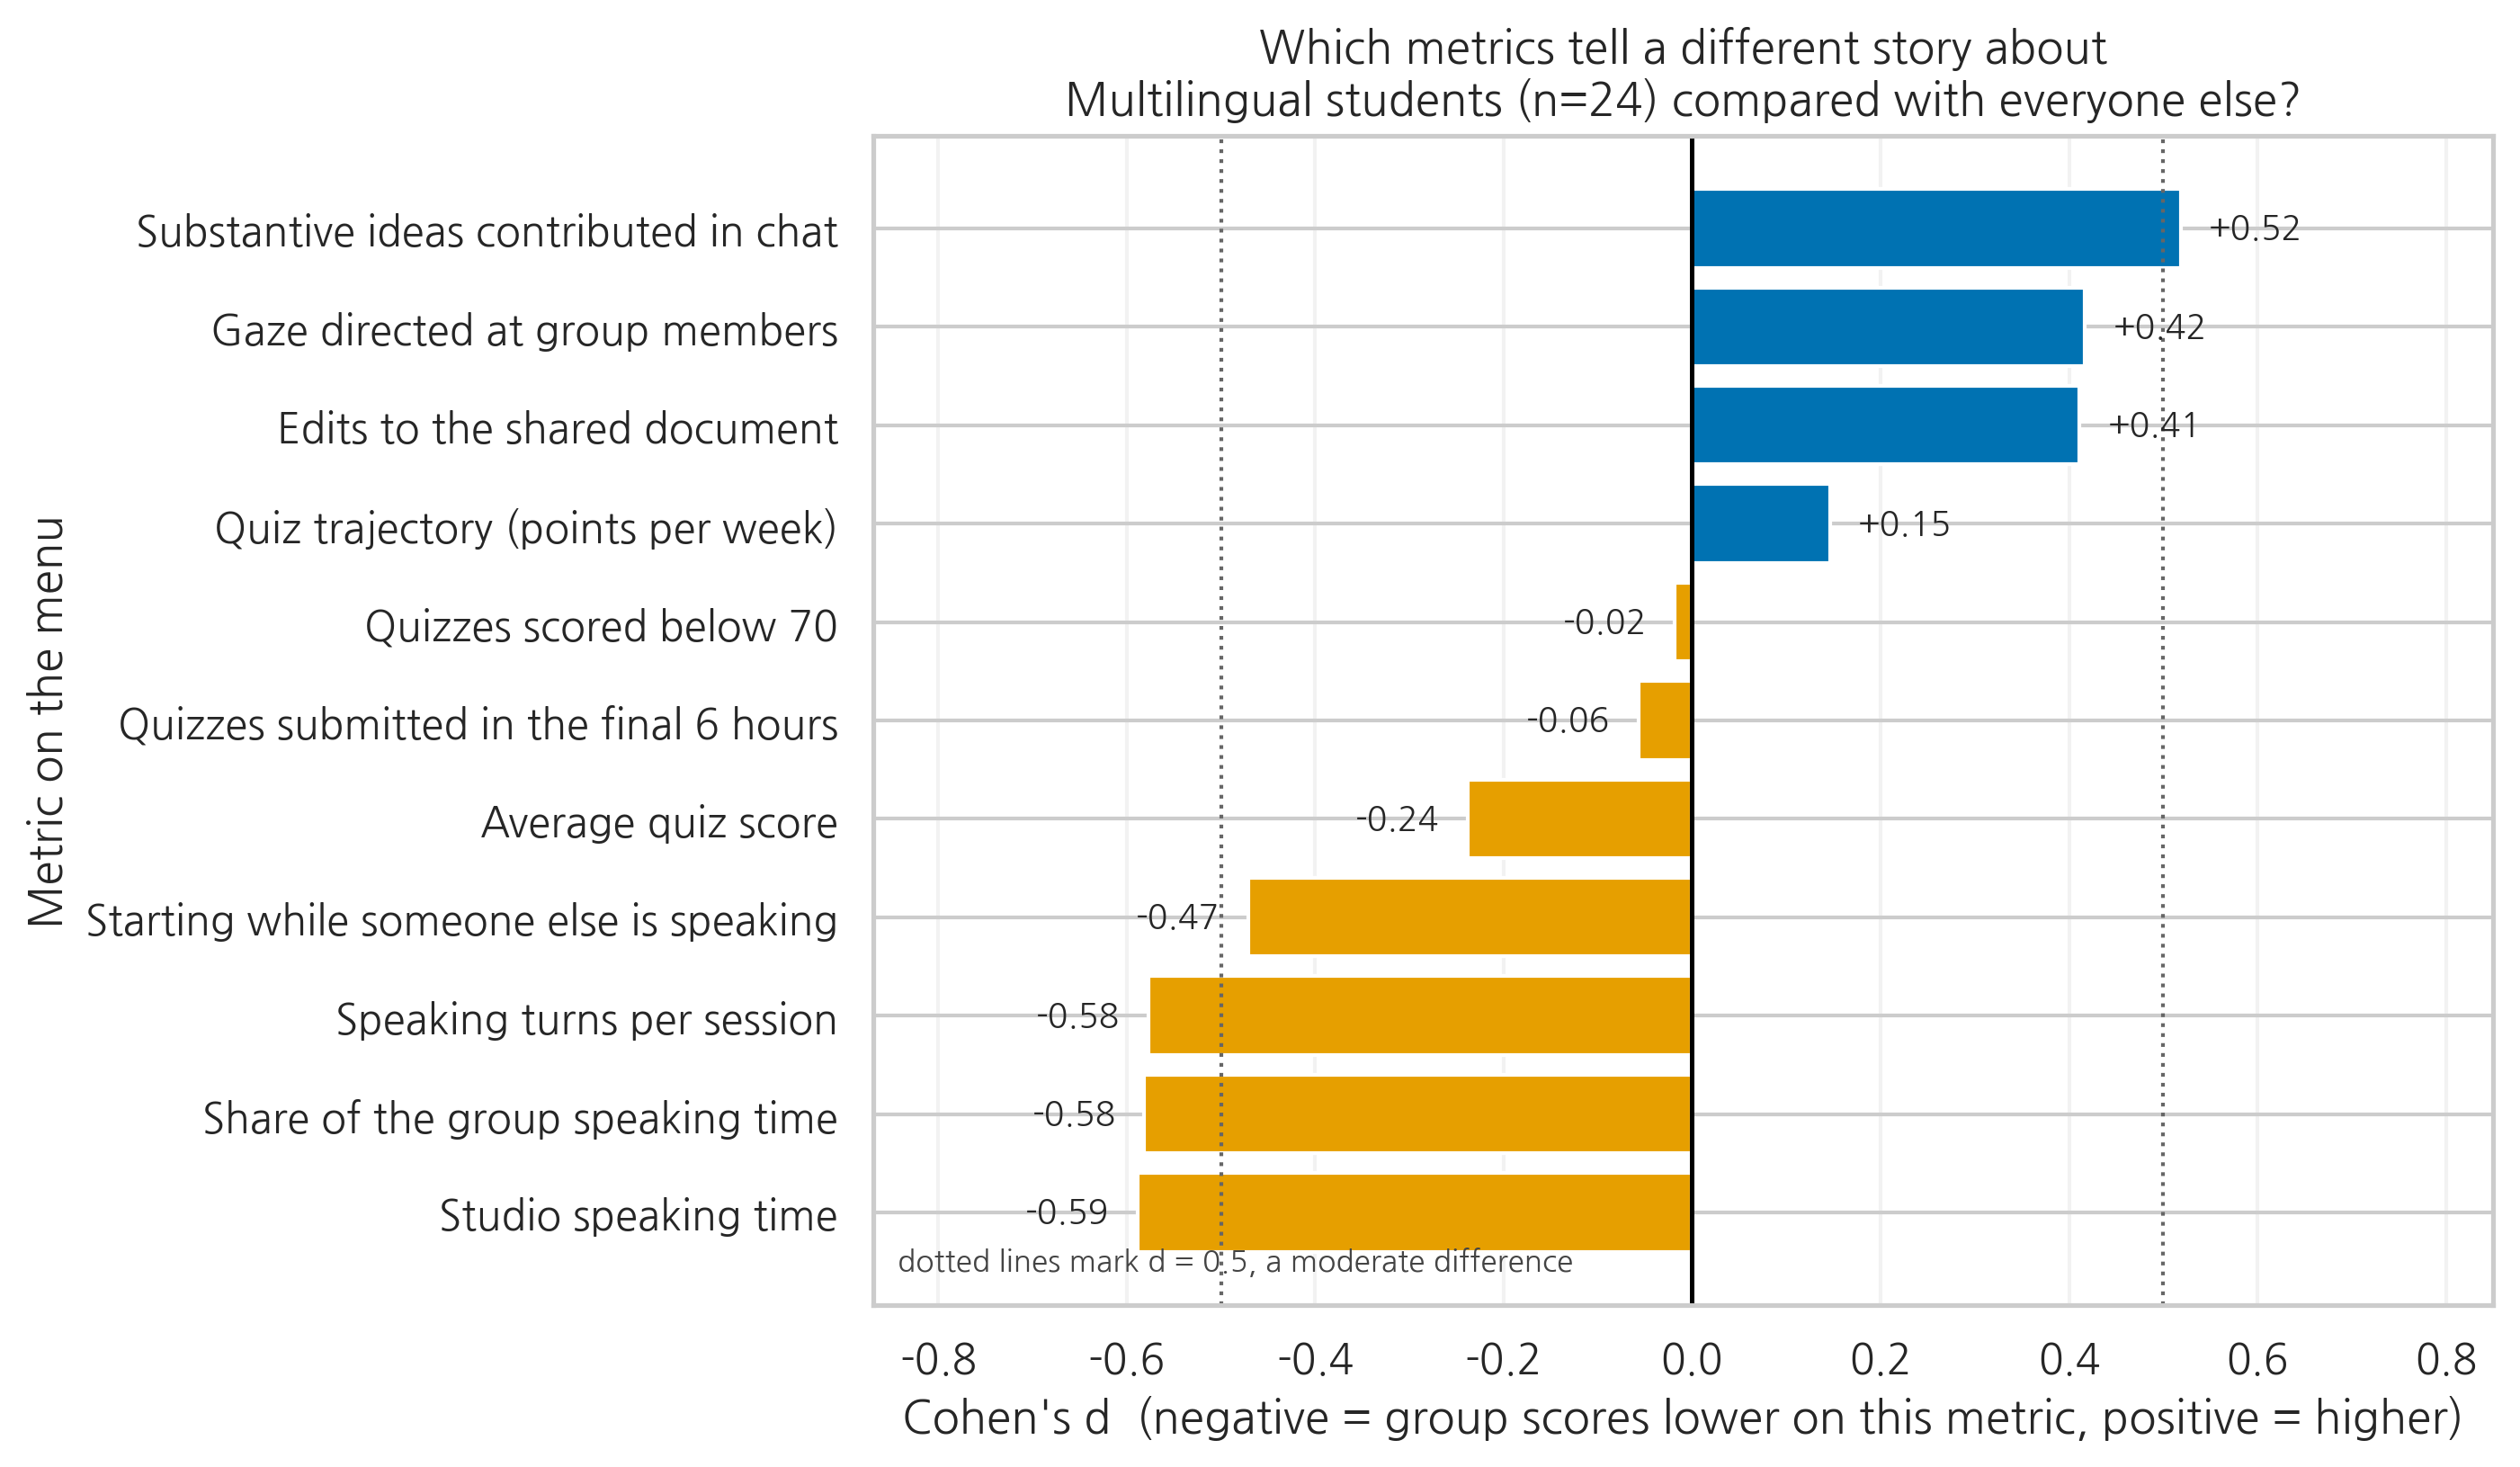

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
colors = ['#E69F00' if v < 0 else '#0072B2' for v in gap['d']]
bars = ax.barh(gap['label'], gap['d'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
for x, style in [(-0.5, ':'), (0.5, ':')]:
    ax.axvline(x, color='#666666', linewidth=1, linestyle=style)
for bar, v in zip(bars, gap['d']):
    off = 0.03 if v >= 0 else -0.03
    ax.text(v + off, bar.get_y() + bar.get_height() / 2, f'{v:+.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlabel("Cohen's d  (negative = group scores lower on this metric, positive = higher)")
ax.set_ylabel('Metric on the menu')
ax.set_title(f'Which metrics tell a different story about\n{group_label} (n={int(mask.sum())})'
             f' compared with {other_label.lower()}?')
ax.set_xlim(min(gap['d'].min() - 0.28, -0.85), max(gap['d'].max() + 0.28, 0.85))
ax.text(0.015, 0.03, 'dotted lines mark d = 0.5, a moderate difference',
        transform=ax.transAxes, fontsize=8, color='#444444')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation prompt.** With the default comparison group, the picture is not "these students
participate less". It is that **the channel decides the answer.** Speaking time, speaking turns, and
share of the floor all run moderately *below* the rest of the class, around half a standard
deviation. Ideas contributed in chat, document edits, and gaze at peers all run *above* it. The
grade metrics sit near zero, with average quiz score down by only about a quarter of a standard
deviation and quiz trajectory slightly up.

So a view built on speaking time and a view built on chat ideas would generate two opposite lists of
"students to worry about" from the same 120 people and the same eight sessions.

Discuss, with the persona cards in front of you:

1. Which persona's fear does the speaking-time version of this dashboard confirm, word for word?
2. If you had to keep exactly one participation metric, which one, and what do you owe the students
   the other one would have found?
3. Change `COMPARE_GROUP` to `'works_15plus'` and re-run the last two cells. The pattern is
   different and weaker. What does it mean that the metric menu is fairer to one group than another?

## 5. 🔁 The swap: read your own sketch through someone else's eyes

This is the core move of the studio. You just built something for one person. Now sit in a different
chair and read it back.

The next cell does the mechanical part: it takes your metric set and reports, for each of the other
three personas, what they can actually do with each metric and which of their fears it touches. The
mechanical part is only a prompt. The real critique is the sentence you say afterwards.

In [10]:
def critique(metrics, designed_for, viewer):
    p, v = PERSONAS[designed_for], PERSONAS[viewer]
    act_col = f'act_{viewer}'
    words = {0: 'CANNOT ACT on this', 1: 'can act, but only after a conversation',
             2: 'CAN ACT directly this week'}
    print('-' * 78)
    print(f"{v['emoji']}  {v['name']} ({viewer}) reads a view built for {p['name']} ({designed_for})")
    print(f"   They arrive asking: \"{v['question']}\"  (grain they need: {v['grain']})")
    print(f"   Access reality: {v['access_reality']}")
    print()
    dead, scary = 0, []
    for m in metrics:
        row = CATALOG.loc[m]
        score = int(row[act_col])
        flag = viewer in str(row['fears']).split(',')
        if score == 0:
            dead += 1
        if flag:
            scary.append(row['label'])
        mark = '  <-- touches a stated fear' if flag else ''
        print(f"   {row['label']:<42} {words[score]}{mark}")
        print(f"      {'':<42} often mistaken for: {row['mistaken_for']}")
    print()
    print(f"   Verdict: {dead} of {len(metrics)} metrics are inert for this person.")
    if scary:
        print(f"   Touches their fears: {'; '.join(scary)}")
    if v['grain'] != p['grain']:
        print(f"   Grain mismatch: this view thinks in '{p['grain']}', they need '{v['grain']}'.")

others = [k for k in PERSONAS if k != MY_PERSONA]
for other in others:
    critique(MY_METRICS, MY_PERSONA, other)
print('-' * 78)

------------------------------------------------------------------------------
🎓  Malik Ferrer (student) reads a view built for Dana Okonkwo (teacher)
   They arrive asking: "What does this say I should do differently, and is it even about me?"  (grain they need: self)
   Access reality: Sees his own grades. Usually sees none of the process data about himself.

   Average quiz score                         can act, but only after a conversation  <-- touches a stated fear
                                                 often mistaken for: how much this student has learned
   Quiz trajectory (points per week)          CAN ACT directly this week  <-- touches a stated fear
                                                 often mistaken for: effort, or momentum
   Share of the group speaking time           can act, but only after a conversation  <-- touches a stated fear
                                                 often mistaken for: dominance, or its opposite
   Substantive ideas con

### 📊 The whole menu, crossed with the whole room

The printout above covers the metrics you chose. This heatmap covers all eleven, so you can see the
structure: which parts of the menu are actionable for whom, and where the fears cluster.

Darker means more actionable. A `!` marks a cell where the metric touches that person's stated fear.
The interesting cells are the dark ones with a `!`: metrics somebody can act on *and* has reason to
dread. Those are the cells that need a co-design conversation, not a default setting.

In [11]:
persona_order = ['teacher', 'student', 'advisor', 'parent']
z = CATALOG[[f'act_{k}' for k in persona_order]].values.astype(float)
labels = [CATALOG.loc[m, 'label'] for m in METRIC_KEYS]
txt = [['!' if pk in str(CATALOG.loc[m, 'fears']).split(',') else ''
        for pk in persona_order] for m in METRIC_KEYS]
cols = [f"{PERSONAS[k]['emoji']} {PERSONAS[k]['name'].split()[0]}<br>({k})" for k in persona_order]

# The same information as a table, so it survives even if the interactive chart does not load.
act_table = CATALOG[[f'act_{k}' for k in persona_order]].copy()
act_table.columns = persona_order
act_table.insert(0, 'metric', CATALOG['label'])
act_table['touches fear of'] = CATALOG['fears'].replace('', 'nobody')
print('Actionability, 0 = cannot act, 1 = after a conversation, 2 = directly this week')
print(act_table.to_string(index=False))
print()
print('Metrics nobody can act on:',
      ', '.join(act_table.loc[act_table[persona_order].sum(axis=1) == 0, 'metric']) or 'none')
print('Total actionable weight per stakeholder (max 22):')
print(act_table[persona_order].sum().to_string())

fig = go.Figure(go.Heatmap(
    z=z, x=cols, y=labels, text=txt, texttemplate='%{text}',
    textfont=dict(size=20, color='#B00020'),
    colorscale='Blues', zmin=0, zmax=2, xgap=3, ygap=3,
    colorbar=dict(title='Can act?', tickvals=[0, 1, 2],
                  ticktext=['0 no', '1 after talking', '2 directly']),
    hovertemplate='%{y}<br>%{x}<br>actionability: %{z}<extra></extra>'))
fig.update_layout(
    title=dict(text='Who can actually do something about each metric?<br>'
                    '<sub>Darker = more actionable. A red ! means the metric touches that '
                    'person\'s stated fear.</sub>'),
    xaxis_title='Stakeholder', yaxis_title='Metric on the menu',
    height=560, margin=dict(l=40, r=40, t=110, b=60))
fig.show()

Actionability, 0 = cannot act, 1 = after a conversation, 2 = directly this week
                                 metric  teacher  student  advisor  parent        touches fear of
                     Average quiz score        2        1        2       1         student,parent
      Quiz trajectory (points per week)        2        2        2       1                student
                Quizzes scored below 70        2        1        2       0 student,advisor,parent
 Quizzes submitted in the final 6 hours        1        2        1       0         student,parent
                   Studio speaking time        2        1        0       0                student
       Share of the group speaking time        2        1        0       0                student
             Speaking turns per session        2        1        0       0                student
  Substantive ideas contributed in chat        2        1        0       0                 nobody
           Edits to the shared documen

**Interpretation prompt.** Look down the parent column. Almost every cell is 0 or 1, and the access
reality on Bea Njoroge's card says she may legally see none of it. Two design responses are
available: build her a stripped-down panel, or build a consent conversation and no panel at all.
Argue for one for two minutes.

Then look across the studio metrics row band (speaking time, share, turns, gaze). The teacher can act
on most of them and the advisor can act on none. Bang and Vossoughi (2016) would ask what the
relations are that this pattern reproduces. Who ends up being the object of the measurement, and who
ends up holding it?

## 6. 🕰️ Retroactive design audit: the semester we already built

Here is the uncomfortable part. We have spent eight weeks building analytics artifacts about
students and studio groups, and we did it the way the field usually does it: researchers deciding
what to measure, with the measured parties absent from the room.

The next cell lists every artifact from weeks 3 through 10, names the design decision each one
quietly made, and asks you to score how much voice each persona should have had, from 0 to 3:

- `0` no legitimate stake
- `1` should have been informed
- `2` should have been consulted before it was built
- `3` should have held a veto

The dictionary comes pre-filled with the instructor's first guess. **It is a first guess and you are
expected to argue with it.** Change numbers, re-run, and be ready to defend one cell you moved.

One nuance worth catching: week 10 is FractionQuest, played by middle schoolers in grades 6 and 7.
The same four persona labels carry very different weight when the learner is 12 years old.

In [12]:
ARTIFACTS = {
    'W3  at-risk model + bias audit':      'Decided that low activity means risk, then audited who that mislabels.',
    'W4  teacher dashboard':               'Decided which three panels a teacher sees first, and what she sees never.',
    'W5  forum text analytics':            'Turned students written words into topics and discourse-move tags.',
    'W6  multimodal participation':        'Defined participation across speech, chat, and document edits.',
    'W7  SRL trace lab':                   'Labeled patterns of tutor use as good strategy or as hint spam.',
    'W8  forum network + procrastination': 'Named four students connectors, and named late submission a risk factor.',
    'W9  collaboration analytics':         'Scored groups on talk balance and linked it to product quality.',
    'W10 game and emotional analytics':    'Read middle schoolers self-reported emotion as a predictor of quitting.',
}

# ✏️ EDIT THE NUMBERS: 0 no stake, 1 inform, 2 consult, 3 veto.
#    Order is [teacher, student, advisor, parent].
AUDIT = {
    'W3  at-risk model + bias audit':      [3, 3, 2, 1],
    'W4  teacher dashboard':               [3, 2, 1, 0],
    'W5  forum text analytics':            [2, 3, 0, 1],
    'W6  multimodal participation':        [3, 3, 0, 1],
    'W7  SRL trace lab':                   [2, 3, 1, 0],
    'W8  forum network + procrastination': [2, 3, 1, 1],
    'W9  collaboration analytics':         [3, 3, 0, 0],
    'W10 game and emotional analytics':    [2, 3, 1, 3],
}

audit_df = pd.DataFrame(AUDIT, index=persona_order).T
audit_df.index.name = 'artifact'
print('Design decision each artifact quietly made:')
for k, v in ARTIFACTS.items():
    print(f'  {k:<36} {v}')
print()
print('Voice scores (0 none, 1 inform, 2 consult, 3 veto):')
print(audit_df.to_string())
print()
print('Total voice per stakeholder across the semester (max 24):')
print(audit_df.sum().to_string())

Design decision each artifact quietly made:
  W3  at-risk model + bias audit       Decided that low activity means risk, then audited who that mislabels.
  W4  teacher dashboard                Decided which three panels a teacher sees first, and what she sees never.
  W5  forum text analytics             Turned students written words into topics and discourse-move tags.
  W6  multimodal participation         Defined participation across speech, chat, and document edits.
  W7  SRL trace lab                    Labeled patterns of tutor use as good strategy or as hint spam.
  W8  forum network + procrastination  Named four students connectors, and named late submission a risk factor.
  W9  collaboration analytics          Scored groups on talk balance and linked it to product quality.
  W10 game and emotional analytics     Read middle schoolers self-reported emotion as a predictor of quitting.

Voice scores (0 none, 1 inform, 2 consult, 3 veto):
                                     teache

In [13]:
level_words = {0: 'none', 1: 'inform', 2: 'consult', 3: 'veto'}
z2 = audit_df.values.astype(float)
txt2 = [[level_words[int(v)] for v in row] for row in z2]

fig = go.Figure(go.Heatmap(
    z=z2, x=cols, y=list(audit_df.index), text=txt2, texttemplate='%{text}',
    textfont=dict(size=11, color='#111111'),
    colorscale='Purples', zmin=0, zmax=3, xgap=3, ygap=3,
    colorbar=dict(title='Voice', tickvals=[0, 1, 2, 3],
                  ticktext=['0 none', '1 inform', '2 consult', '3 veto']),
    hovertemplate='%{y}<br>%{x}<br>voice level: %{z}<extra></extra>'))
fig.update_layout(
    title=dict(text='Retroactive design audit: who should have had a voice, weeks 3 to 10?<br>'
                    '<sub>Darker = more say in the design. These are your judgments, not findings.</sub>'),
    xaxis_title='Stakeholder', yaxis_title='Semester artifact',
    height=560, margin=dict(l=40, r=40, t=110, b=60))
fig.show()

**Interpretation prompt.** Read the column totals printed above the heatmap, not just the colors.
In the default scoring the student column is the darkest and the artifacts were all built without a
single student in the room. That gap between "should have had a voice" and "had a voice" is the
thing Prieto-Alvarez and colleagues (2018) are writing about when they insist on co-designing
*with* learners rather than for them.

Now the harder question, and the one to carry into your Rough Draft: pick the one artifact where
you moved a score, and say what would have *changed about the artifact itself* if that stakeholder
had been consulted. Not what would have felt better. What would be different on the screen.

## 7. ✏️ Your turn (stretch, optional)

Only if you finish early. Nothing later depends on these.

1. **Add a persona.** Copy one of the entries in `PERSONAS`, change the key, and write a fifth
   stakeholder this course has ignored: a teaching assistant, a disability services coordinator, a
   department chair, an admissions office. Then add an `act_<yourkey>` column to `CATALOG` and see
   how the heatmap changes.
2. **Build the refusal list.** Write the three metrics you would refuse to display to *any* of the
   four personas, and the sentence you would put in the interface where they would have gone.
3. **Two-channel participation.** Make a scatter of `talk_share` against `ideas_in_chat`, color the
   points by `multilingual`, and mark the students who sit in the low-talk, high-idea quadrant.
   That quadrant is a list of names. Decide what a responsible tool does with it.

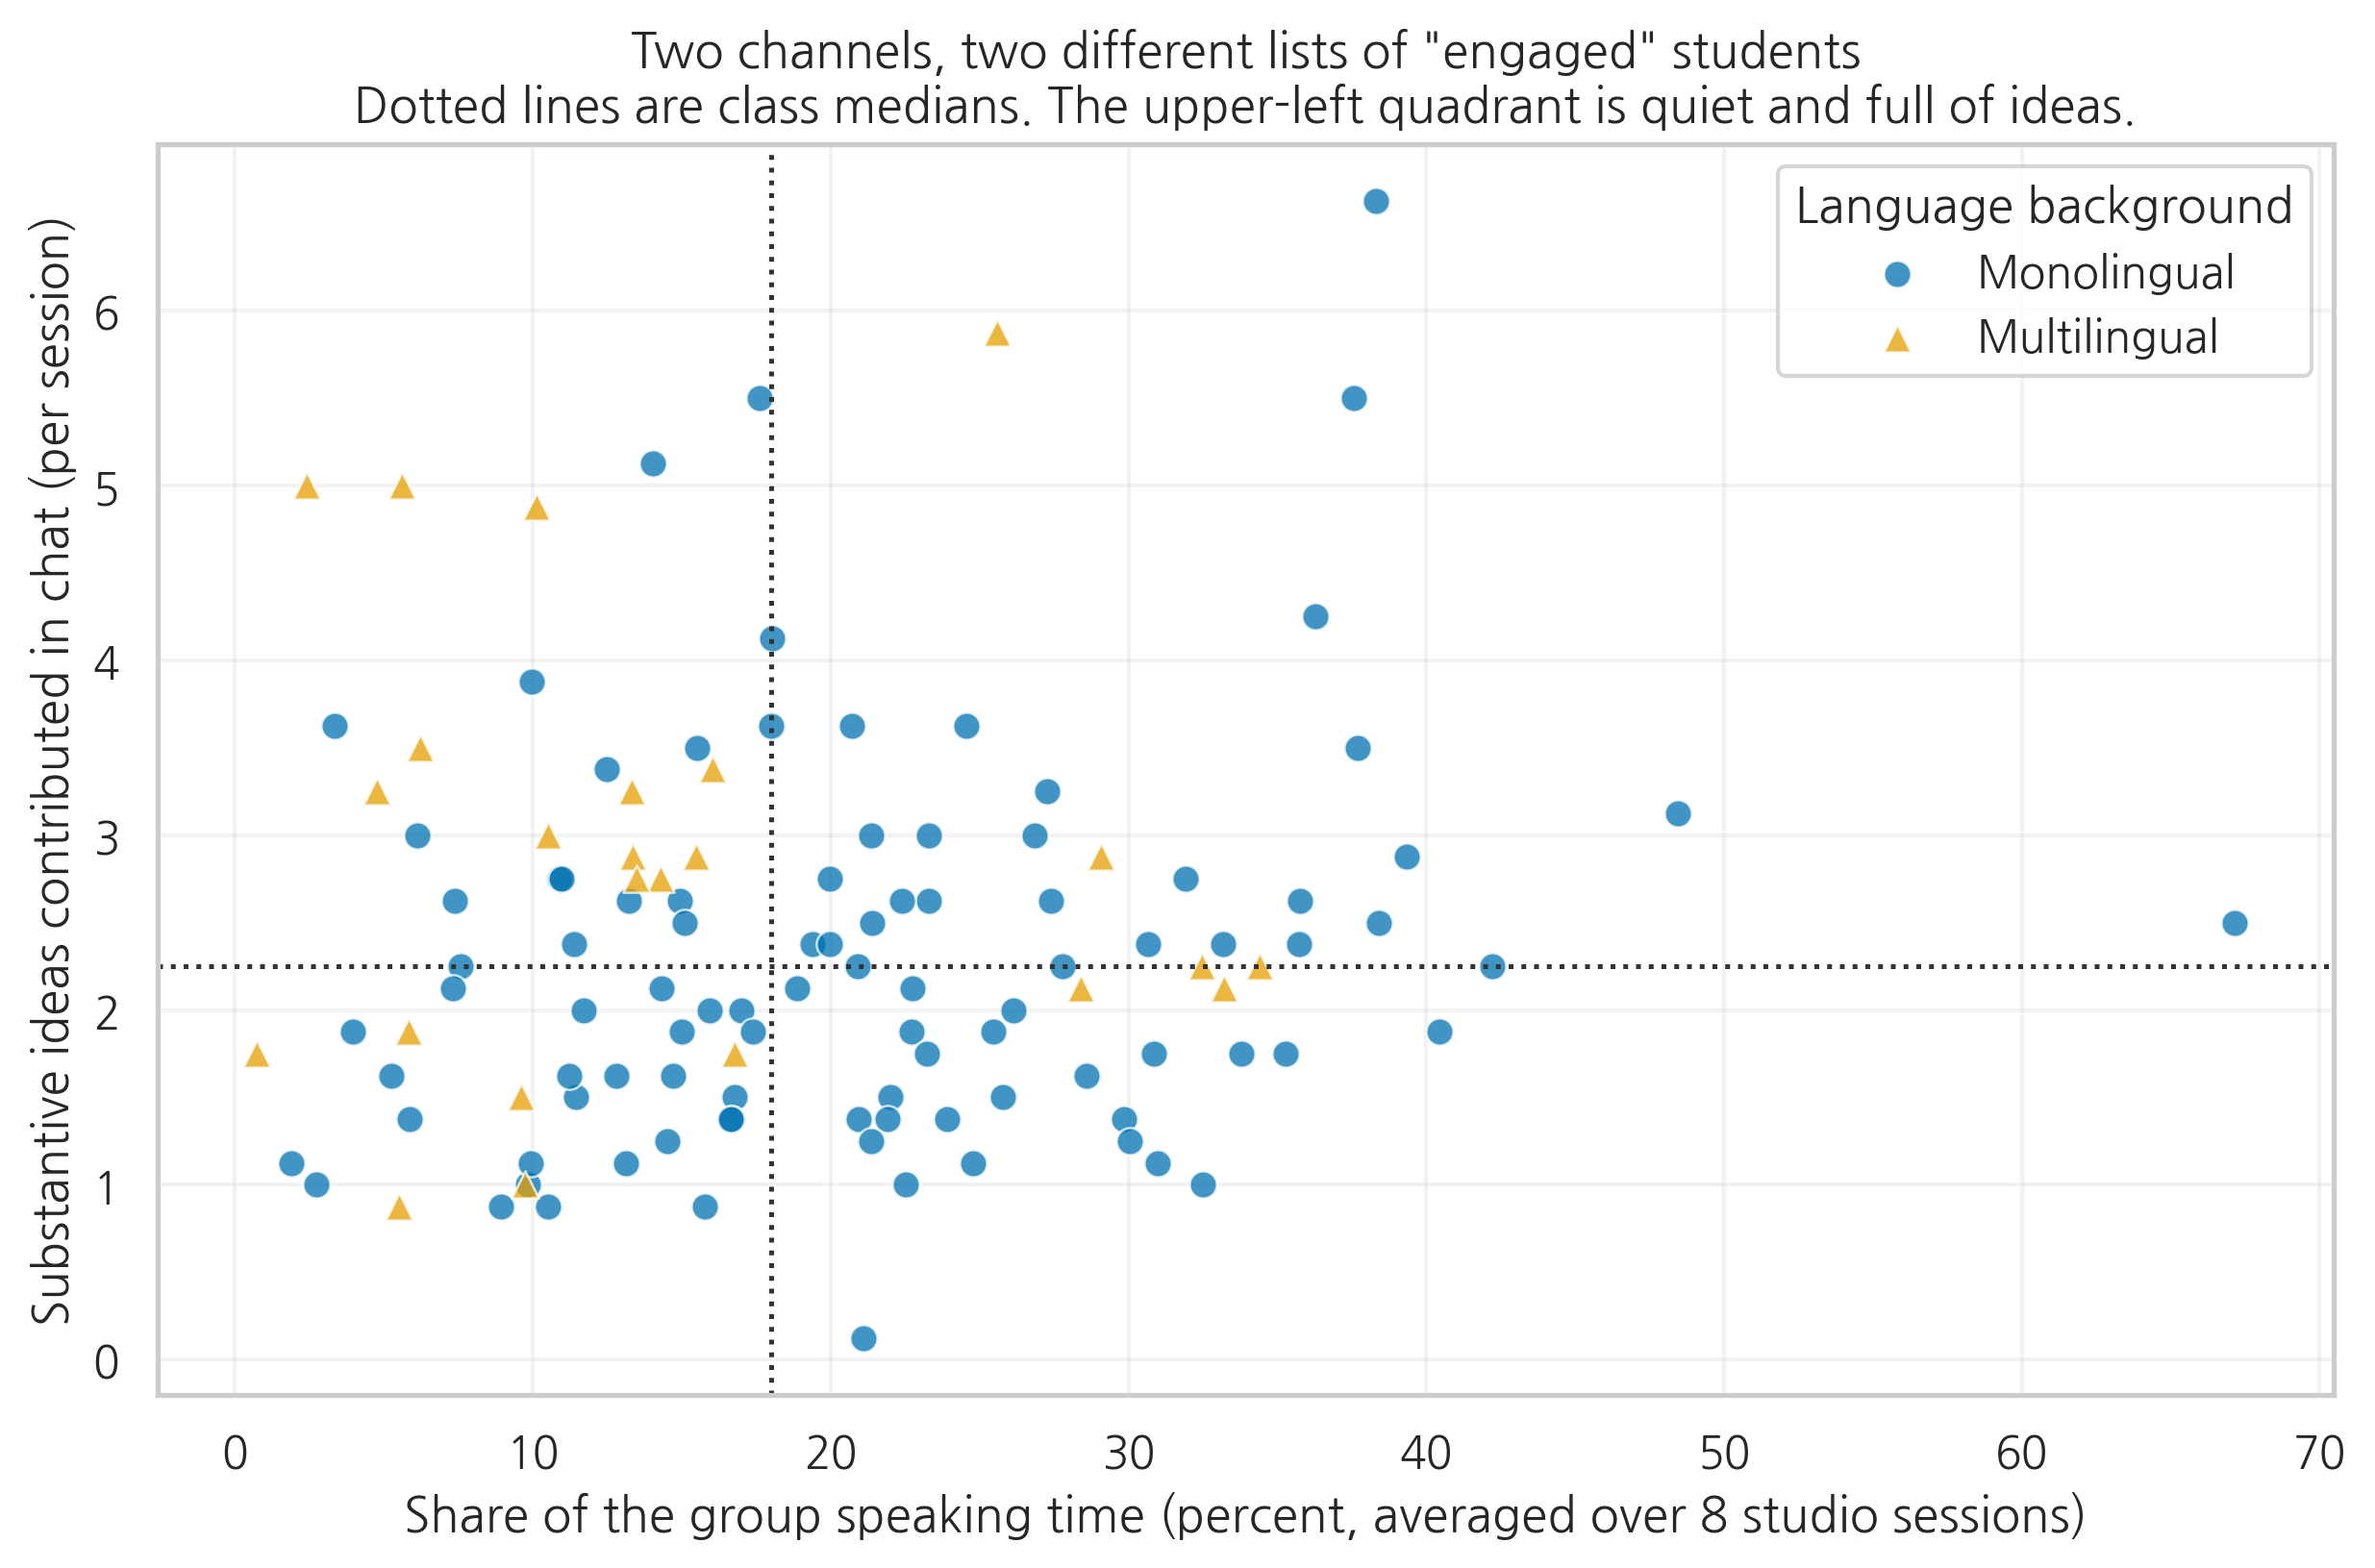

27 students sit in the quiet, idea-rich quadrant (12 of them multilingual, out of 24 multilingual students in the class).
Their mean quiz score is 75.8 against a class mean of 75.7.


In [14]:
# A worked start for stretch 3. Change nothing and it runs; edit it and it is yours.
fig, ax = plt.subplots(figsize=(8.4, 5.6))
for flag, color, marker, lab in [(0, '#0072B2', 'o', 'Monolingual'),
                                 (1, '#E69F00', '^', 'Multilingual')]:
    sub = M[M['multilingual'] == flag]
    ax.scatter(sub['talk_share'], sub['ideas_in_chat'], c=color, marker=marker,
               s=46, alpha=0.75, edgecolor='white', linewidth=0.6, label=lab)
ax.axvline(M['talk_share'].median(), color='#333333', linestyle=':', linewidth=1.2)
ax.axhline(M['ideas_in_chat'].median(), color='#333333', linestyle=':', linewidth=1.2)
ax.set_xlabel('Share of the group speaking time (percent, averaged over 8 studio sessions)')
ax.set_ylabel('Substantive ideas contributed in chat (per session)')
ax.set_title('Two channels, two different lists of "engaged" students\n'
             'Dotted lines are class medians. The upper-left quadrant is quiet and full of ideas.')
ax.legend(title='Language background', loc='upper right', frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

quiet_ideas = M[(M['talk_share'] < M['talk_share'].median()) &
                (M['ideas_in_chat'] > M['ideas_in_chat'].median())]
print(f'{len(quiet_ideas)} students sit in the quiet, idea-rich quadrant '
      f'({int(quiet_ideas["multilingual"].sum())} of them multilingual, '
      f'out of {int(M["multilingual"].sum())} multilingual students in the class).')
print(f'Their mean quiz score is {quiet_ideas["avg_quiz"].mean():.1f} '
      f'against a class mean of {M["avg_quiz"].mean():.1f}.')

**Interpretation prompt.** The upper-left quadrant is not an anomaly to be explained away. It is a
list of specific people whom a speaking-time dashboard would put on a worry list and a chat-ideas
dashboard would put on a leaderboard. Before you design anything for the Rough Draft, decide what
your system does when two of its own metrics disagree about the same person.

## 💬 Reflection

Write a few sentences for each. These are the questions the discussion block will open with, and
they are also usable material for your Rough Draft.

**1. Design starts before the data (Carvalho, Martinez-Maldonado, Tsai, Markauskaite, and De Laat, 2022).**
Their argument is that designing for learning in an AI world means starting from the activity, the
purposes, and the setting rather than from the traces a system happens to produce. Name one metric
on today's menu that exists only because the sensor exists. What activity would you have had to
design first for that metric to be worth reading?

**2. Participation is a relation, not a property (Bang and Vossoughi, 2016).**
Participatory design research, in their framing, is about studying and changing relations, not about
collecting stakeholder preferences and then proceeding as planned. Look at your decision-rights
heatmap. Which relation does your sketch reproduce, and which one would have to change for the
sketch to be different?

**3. Co-designing with learners (Prieto-Alvarez, Martinez-Maldonado, and Anderson, 2018).**
They work with learners as designers rather than as data sources. In your retroactive audit, the
student column probably carries the most weight and had the least presence. Pick one artifact from
weeks 3 to 10 and describe, concretely, what a 45-minute co-design session with five EDUC 1010
students would have had to produce for the artifact to change.

**4. Turn it on yourself.** Your course research project proposes a system, an analysis, or an
intervention. Who has decision rights over the thing you are proposing, and who is measured by it?
If those are different people, say in one sentence how your Rough Draft handles that.

## ✅ Submission checklist

**This notebook is not submitted.** Week 11 has no mini project. It is a studio, and the artifact you
leave with is the argument you can now make in your writing.

Still, do these two things before you close the tab:

- [ ] **Save your copy.** In Colab: `File > Save a copy in Drive`. Your persona choice, your metric
      set, and your audit numbers are the record of what you decided today.
- [ ] **Paste two things into your project notes**: your metric set with the one-sentence defense of
      why those and not others, and the one audit cell you moved with your reason for moving it.

**Due this week, submitted separately on Canvas (not from this notebook):**

- [ ] **Course Research Project Rough Draft**, per the Week 11 Rough Draft Guidelines. Word document,
      APA 7, building toward the 20-page final.
- [ ] **AI interaction log**, pasted into a Word file and attached to the Canvas "AI Reflection"
      submission, not into the text box. Per the course AI policy, any AI use in drafting must be
      documented: the tool, the prompts, and what you did with the output.
- [ ] **AI reflection**, typed into the text box on that same page: copy in and answer the four
      questions from the syllabus. Undisclosed AI use is an Honor Code violation, and disclosed use is
      completely fine.

If you used an AI tool while working through this notebook, that counts and belongs in the log too.

## Appendix: solutions to the "✏️ Your turn" cells

There is no single right answer in a co-design studio, so these are **worked examples**, not keys.
Compare your reasoning against them and note where you disagree. Disagreeing well is the skill.

### Section 3: a defensible metric set for each persona

| Persona | A defensible set | Why |
|---|---|---|
| Teacher (Dana) | `quiz_trend`, `low_quiz_count`, `ideas_in_chat` | Trend and low-quiz count are things she can act on by Thursday. Ideas in chat catches students her eyes miss in a loud room. She does not need `avg_quiz`, she already has the gradebook open. |
| Student (Malik) | `quiz_trend`, `last_minute_rate`, `ideas_in_chat` | All three are things he controls this week. No class comparison at all, which removes the fear of public ranking and loses nothing he can act on. |
| Advisor (Ana) | `quiz_trend`, `low_quiz_count` | Two metrics, both about direction of travel. Everything from inside the studio is outside her decision rights and would only manufacture false alarms. |
| Parent (Bea) | none, plus a consent flow | Her decision rights are conversational. The defensible design is a prompt to her student to share what they choose, not a panel. |

### Section 6: the audit cell most people move

The common move is `W10 game and emotional analytics`, parent, from `1` to `3`. The learners are 12
years old, the data are self-reported emotion, and the analysis predicts quitting. Parental veto
becomes a serious position rather than an overreach, and the same argument does not transfer to the
undergraduates in weeks 3 to 9. That the persona set has to be re-weighted by learner age is itself
a design finding worth a paragraph in a Rough Draft.

### The stretch: a fifth persona worth adding

The teaching assistant. They have close to a teacher's access and close to a student's lack of
authority, which makes almost every cell in their column a `1`, and a column of `1`s is a good
description of burnout.

In [15]:
# Worked example for Section 3: run the same sketch for a different persona and metric set,
# then read the two side by side and say what changed and why.
sketch_view('student', ['quiz_trend', 'last_minute_rate', 'ideas_in_chat'], FOCUS_STUDENT).show()

In [16]:
# Worked example for Section 6: compare two audit scorings and show only where they disagree.
ALT_AUDIT = dict(AUDIT)
ALT_AUDIT['W10 game and emotional analytics'] = [2, 3, 1, 3]
ALT_AUDIT['W5  forum text analytics'] = [2, 3, 0, 2]
ALT_AUDIT['W9  collaboration analytics'] = [3, 3, 1, 0]

alt_df = pd.DataFrame(ALT_AUDIT, index=persona_order).T
diff = (alt_df - audit_df)
changed = diff.loc[(diff != 0).any(axis=1)]
if len(changed):
    print('Cells where the alternative scoring disagrees with yours (positive = more voice):')
    print(changed.to_string())
    print()
    print('Defend or reject each one in a sentence. A score you cannot defend is a score you borrowed.')
else:
    print('Your scoring already matches this alternative. Find someone in the room who disagrees.')

Cells where the alternative scoring disagrees with yours (positive = more voice):
                             teacher  student  advisor  parent
W5  forum text analytics           0        0        0       1
W9  collaboration analytics        0        0        1       0

Defend or reject each one in a sentence. A score you cannot defend is a score you borrowed.
